# Оценка вакантности по домам (метод №2)

Самый главный шаг с попыткой ответа на основной вопрос исследования.

## Идея

Использовать опросные данные, чтобы научиться по характеристикам квартир (площадь, этаж, свойства дома и другие) предсказывать количество живущих в них людей. Далее на базе такого предсказания можно оценить число живущих в доме, и сравнив его с числом зарегистрированных (то есть номинально живущих), дать оценку числа вакантных квартир.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)

In [2]:
flats_mapping = pd.read_parquet("flats.parquet")
flats_properties = pd.read_parquet("flats_area.parquet")
houses = pd.read_csv("../intercarto-intergis/data/export-reestrmkd-77-20250301.zip", sep=";", decimal=",")
repair_data = pd.read_csv("../intercarto-intergis/data/export-kr1_1-77-20250301.zip", sep=";", decimal=",")

In [13]:
houses[(houses["playground"] == 499) & (houses["sportsground"] == 499)].sample(5) # 499 = да, 500 = нет, 498 = нет данных (?)

,id,region_id,area_id,city_id,street_id,shortname_region,formalname_region,shortname_area,formalname_area,shortname_city,formalname_city,shortname_street,formalname_street,house_number,building,block,letter,address,houseguid,management_organization_id,built_year,exploitation_start_year,project_type,house_type,is_alarm,method_of_forming_overhaul_fund,floor_count_max,floor_count_min,entrance_count,elevators_count,energy_efficiency,quarters_count,living_quarters_count,unliving_quarters_count,area_total,area_residential,area_non_residential,area_common_property,area_land,parking_square,playground,sportsground,other_beautification,foundation_type,floor_type,wall_material,basement_area,chute_type,chute_count,electrical_type,electrical_entries_count,heating_type,hot_water_type,cold_water_type,sewerage_type,sewerage_cesspools_volume,gas_type,ventilation_type,firefighting_type,drainage_type
2819,7598840,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,d329f568-4475-4fee-92e7-c8faf75206b8,г,Москва,NaN,NaN,NaN,NaN,ул,Бехтерева,13,NaN,1,NaN,"г. Москва, ул. Бехтерева, д. 13, к. 1",8a857b3a-dfd1-472d-a4be-fd3363a5d460,8930376.0,2000.0,2000.0,индивидуальный проект,Многоквартирный дом,Нет,На специальном счете у регионального оператора,14.0,14.0,1.0,2.0,D,81,80.0,1.0,5496.5,5476.2,20.3,941.0,0.0,0.0,499,499,0,Ленточный,Железобетонные,Железобетон,542.7,На лестничной клетке,1.0,Центральное,1.0,Центральное,Закрытая с приготовлением горячей воды на ЦТП,Центральное,Центральное,0.0,Отсутствует,Приточно-вытяжная вентиляция,Пожарные гидранты,Внутренние водостоки
16753,7750384,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,6a6d0bb0-c345-4891-9388-50fb7fa681bd,г,Москва,NaN,NaN,NaN,NaN,ул,Международная,13,NaN,NaN,NaN,"г. Москва, ул. Международная, д. 13",bf6c67d2-0059-4e49-867e-d015d3f742dc,8916819.0,1955.0,1955.0,индивидуальный проект,Многоквартирный дом,Нет,На счете регионального оператора,4.0,4.0,1.0,0.0,Не присвоен,21,19.0,2.0,1283.0,1022.0,261.0,403.0,0.0,0.0,499,499,Не имеется,Бетонные столбы,Железобетонные,Кирпич,150.0,Отсутствует,0.0,Центральное,1.0,Центральное,Закрытая с приготовлением горячей воды на ЦТП,Центральное,Центральное,0.0,Центральное,Приточно-вытяжная вентиляция,Отсутствует,Наружные водостоки
27605,7579344,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,7e8c93c6-70e5-446f-b4c4-d7f2ec8837dd,г,Москва,NaN,NaN,NaN,NaN,ул,Соколиной Горы 9-я,3,NaN,NaN,NaN,"г. Москва, ул. Соколиной Горы 9-я, д. 3",f81796f2-75e0-40c6-9fbe-801d384d35c9,7552674.0,1967.0,1967.0,индивидуальный проект,Многоквартирный дом,Нет,На счете регионального оператора,9.0,9.0,8.0,8.0,C,264,256.0,8.0,13147.0,10891.0,2255.5,59.1,0.0,93.0,499,499,-,Ленточный,Железобетонные,Кирпич,1932.1,На лестничной клетке,8.0,Центральное,2.0,Центральное,Закрытая с приготовлением горячей воды на ЦТП,Центральное,Центральное,0.0,Центральное,Приточно-вытяжная вентиляция,Отсутствует,Внутренние водостоки
26207,8059594,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,3762c39b-2e29-4a0f-bee7-5efb7aac95b9,г,Москва,NaN,NaN,NaN,NaN,проезд,Саринский,2,NaN,NaN,NaN,"г. Москва, проезд. Саринский, д. 2",2c23dcc0-2826-457a-a4ba-796987bef59f,8916819.0,1945.0,1945.0,нет данных,Многоквартирный дом,Нет,На счете регионального оператора,9.0,9.0,5.0,5.0,Не присвоен,96,94.0,2.0,7702.0,6189.0,1513.0,1152.8,0.0,0.0,499,499,Не имеется,Ленточный,Железобетонные,Кирпич,1152.8,Квартирные,6.0,Центральное,1.0,Центральное,Закрытая с приготовлением горячей воды на ЦТП,Центральное,Центральное,0.0,Центральное,Приточно-вытяжная вентиляция,Отсутствует,Наружные водостоки
29474,7602297,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,52434d18-7efe-4734-8eef-736e2286bfe4,г,Москва,NaN,NaN,NaN,NaN,ул,Текстильщиков 11-я,11,NaN,NaN,NaN,"г. Москва, ул. Текстильщиков 11-я, д. 11",e92b5cf8-350e-417d-85b1-a5007abeff9d,7552922.0,1997.0,1997.0,П-55,Многоквартирный дом,Нет,На счете регионального оператора,14.0,14.0,5.0,10.0,Не присвоен,214,209.0,5.0,29157.8,13971.2,607.7,14578.9,13000.0,920.0,499,499,NaN,Свайный,Железобетонные,Железобетон,1430.0,На лестничной кл

In [7]:
houses["sportsground"].value_counts()

sportsground
500    25626
499     7228
498     1849
Name: count, dtype: int64

In [14]:
houses["playground"].value_counts()

playground
499    17728
500    15166
498     1809
Name: count, dtype: int64

In [32]:
repair_data.head(2)

,subject_rf,mun_obr_oktmo,mun_obr,mkd_code,houseguid,address,commission_year,architectural_monument_category,total_sq,total_rooms_amount,living_rooms_amount,total_rooms_sq,living_rooms_sq,total_ppl,number_floors_max,money_collecting_way,money_ppl_collected,money_ppl_collected_debts,overhaul_funds_spent_all,overhaul_funds_spent_subsidy,overhaul_fund_spent_other,overhaul_funds_balance,update_date_of_information,money_ppl_collected_date,owners_payment,energy_efficiency,alarm_document_date,exclude_date_from_program,inclusion_date_to_program,comment,last_update,house_id
0,город Москва,45397000,Академический район,108367,fa844609-84ef-4f05-8414-74b25c56fce1,60-летия Октября просп. 10/1,1964,NaN,3448.0,71,68,3352.46,2429.13,136,9,Счет регионального оператора,7059.18318,22.57946,1597.26244,NaN,NaN,5461.92074,2025-01-15,01.01.2015,29.66,NaN,NaN,NaN,29.12.2014,NaN,23.01.2025,8004177.0
1,город Москва,45397000,Академический район,104062,6793bac3-20b7-4e42-b53a-73dc9be6c309,60-летия Октября просп. 12,1963,NaN,3457.0,75,68,3251.41,2539.72,129,9,Счет регионального оператора,6772.90899,90.33989,13380.14323,NaN,NaN,-6607.23424,2025-01-15,01.01.2015,29.66,NaN,NaN,NaN,29.12.2014,NaN,23.01.2025,8004180.0


In [28]:
flats_mapping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5318579 entries, 0 to 5318578
Data columns (total 2 columns):
 #   Column                                            Dtype 
---  ------                                            ----- 
 0   Глобальный уникальный идентификатор дома по ФИАС  object
 1   Кадастровый номер                                 object
dtypes: object(2)
memory usage: 81.2+ MB


In [5]:
flats_properties.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4952236 entries, 0 to 92449
Data columns (total 3 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flat_cad_number  object 
 1   flat_area        int64  
 2   flat_floor       float64
dtypes: float64(1), int64(1), object(1)
memory usage: 151.1+ MB


In [29]:
flats_mapping.columns = ["houseguid", "flat_cad_number"]
flats = flats_mapping.merge(flats_properties)

In [30]:
flats.head()

,houseguid,flat_cad_number,flat_area,flat_floor
0,021f35f5-fe8e-4291-b7f1-48eecca62b6e,77:01:0001026:1623,87,2.0
1,021f35f5-fe8e-4291-b7f1-48eecca62b6e,77:01:0001026:1624,123,2.0
2,021f35f5-fe8e-4291-b7f1-48eecca62b6e,77:01:0001026:1625,91,2.0
3,021f35f5-fe8e-4291-b7f1-48eecca62b6e,77:01:0001026:1626,228,2.0
4,021f35f5-fe8e-4291-b7f1-48eecca62b6e,77:01:0001026:1627,154,2.0


In [31]:
flats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4573346 entries, 0 to 4573345
Data columns (total 4 columns):
 #   Column           Dtype  
---  ------           -----  
 0   houseguid        object 
 1   flat_cad_number  object 
 2   flat_area        int64  
 3   flat_floor       float64
dtypes: float64(1), int64(1), object(2)
memory usage: 139.6+ MB


In [9]:
houses.columns

Index(['id', 'region_id', 'area_id', 'city_id', 'street_id',
       'shortname_region', 'formalname_region', 'shortname_area',
       'formalname_area', 'shortname_city', 'formalname_city',
       'shortname_street', 'formalname_street', 'house_number', 'building',
       'block', 'letter', 'address', 'houseguid', 'management_organization_id',
       'built_year', 'exploitation_start_year', 'project_type', 'house_type',
       'is_alarm', 'method_of_forming_overhaul_fund', 'floor_count_max',
       'floor_count_min', 'entrance_count', 'elevators_count',
       'energy_efficiency', 'quarters_count', 'living_quarters_count',
       'unliving_quarters_count', 'area_total', 'area_residential',
       'area_non_residential', 'area_common_property', 'area_land',
       'parking_square', 'playground', 'sportsground', 'other_beautification',
       'foundation_type', 'floor_type', 'wall_material', 'basement_area',
       'chute_type', 'chute_count', 'electrical_type',
       'electrical_entrie

In [25]:
houses_properties = houses[["houseguid"]].copy()
houses_properties["house_construction_year"] = pd.cut(
    x=houses["built_year"],
    bins=[1147, 1920, 1945, 1956, 1970, 1995, 2012, 2025],
    labels=[1, 2, 3, 4, 5, 6, 7],
).astype(float)
houses_properties["house_is_alarm"] = houses["is_alarm"] == "Да"
houses_properties["house_has_elevator"] = houses["elevators_count"] > 0
houses_properties["house_has_chute"] = houses["chute_count"] > 0
houses_properties["house_has_parking"] = houses["parking_square"] > 0
houses_properties["house_wall_material"] = houses["wall_material"].map({
    "Кирпич": 1,
    "Железобетон": 2,
    "Блочные": 2,
    "Панельные": 2,
    "Монолитные": 3,
    "Смешанные": 5,
    "Деревянные": 4,
    "Иные": 6,
    "Железобетонная панель": 2,
    "Шлакобетон (блоки)": 2,
    "Керамзитобетон": 2,  
})
houses_properties["house_cold_water_type"] = houses["cold_water_type"].map({
    "Центральное": 1,
    "Отсутствует": 4,
    "Автономное": 2,
})
houses_properties["house_hot_water_type"] = houses["hot_water_type"].map({
    "Закрытая с приготовлением горячей воды на ЦТП": 1,                                
    "Открытая с отбором сетевой воды на горячее водоснабжение из тепловой сети": 2,
    "Отсутствует": 3,                                                                 
    "Квартирное (квартирный котел)": 2,                                                
    "Закрытая с приготовлением горячей воды на ИТП": 2,                                  
    "Автономная котельная (крышная, встроенно-пристроенная)": 2,                        
    "Печное": 2,
})
houses_properties["house_heating_type"] = houses["heating_type"].map({
    "Центральное": 1,
    "Квартирное отопление (квартирный котел)": 2,
    "Автономная котельная (крышная, встроенно-пристроенная)": 2,
    "Индивидуальный тепловой пункт (ИТП)": 2,
    "Отсутствует": 4,
    "Печное": 3,
})
houses_properties["house_serwage_type"] = houses["sewerage_type"].map({
    "Центральное": 1,
    "Отсутствует": 4,
    "Автономное": 2,
})
houses_properties["house_has_gas"] = houses["gas_type"].map({
    "Центральное": True,
    "Отсутствует": False,
    "Автономное": True,
})

houses_properties.dropna(inplace=True)
houses_properties[houses_properties.select_dtypes(float).columns] = houses_properties.select_dtypes(float).astype(int)
houses_properties["house_has_gas"] = houses_properties["house_has_gas"].astype(bool)

houses_properties.head()

,houseguid,house_construction_year,house_is_alarm,house_has_elevator,house_has_chute,house_has_parking,house_wall_material,house_cold_water_type,house_hot_water_type,house_heating_type,house_serwage_type,house_has_gas
0,521474b9-1d5a-702f-3b75-33ff10263733,5,False,True,True,False,2,1,1,1,1,True
3,4b9cbbad-b371-6ce1-bebe-09e785d0b894,5,False,True,True,False,2,1,1,1,1,False
11,723e2dcf-d203-4dc1-89de-9b41f453916a,1,False,False,True,False,1,1,2,1,1,True
12,8425ff55-ec42-466a-a993-de4e5faaba3b,4,False,True,True,False,1,1,1,1,1,True
13,a8ad9e0b-e0c1-46a7-981c-4d5a598c76ce,3,False,True,True,False,1,1,1,1,1,True


In [19]:
houses_properties.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32122 entries, 0 to 34702
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   houseguid                32122 non-null  object 
 1   house_construction_year  32122 non-null  float64
 2   house_is_alarm           32122 non-null  bool   
 3   house_has_elevator       32122 non-null  bool   
 4   house_has_chute          32122 non-null  bool   
 5   house_has_parking        32122 non-null  bool   
 6   house_wall_material      32122 non-null  float64
 7   house_cold_water_type    32122 non-null  float64
 8   house_hot_water_type     32122 non-null  float64
 9   house_heating_type       32122 non-null  float64
 10  house_serwage_type       32122 non-null  float64
 11  house_has_gas            32122 non-null  bool   
dtypes: bool(5), float64(6), object(1)
memory usage: 2.1+ MB


In [33]:
X_test = flats.merge(houses_properties)

In [34]:
X_test["houseguid"].nunique()

29727

In [36]:
X_test.drop(columns=["houseguid", "flat_cad_number"]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3806758 entries, 0 to 3806757
Data columns (total 13 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   flat_area                int64  
 1   flat_floor               float64
 2   house_construction_year  int64  
 3   house_is_alarm           bool   
 4   house_has_elevator       bool   
 5   house_has_chute          bool   
 6   house_has_parking        bool   
 7   house_wall_material      int64  
 8   house_cold_water_type    int64  
 9   house_hot_water_type     int64  
 10  house_heating_type       int64  
 11  house_serwage_type       int64  
 12  house_has_gas            bool   
dtypes: bool(5), float64(1), int64(7)
memory usage: 250.5 MB


In [13]:
houses_properties["house_has_gas"].value_counts()

house_has_gas
True     21209
False    12106
Name: count, dtype: int64

In [5]:
houses["is_alarm"].value_counts()

is_alarm
Нет    34651
Да        52
Name: count, dtype: int64

In [17]:
houses_properties["wall_material"].value_counts()

wall_material
Кирпич                   11825
Железобетон               7051
Блочные                   4964
Панельные                 4444
Монолитные                3932
Не заполнено              1197
Смешанные                  707
Иные                       410
Деревянные                 164
Железобетонная панель        7
Шлакобетон (блоки)           1
Керамзитобетон               1
Name: count, dtype: int64

In [4]:
kouz_base = pd.read_csv("КОУЖ_2022_Датасет_по_домохозяйствам_основной.csv", sep=";")
kouz_add = pd.read_csv("КОУЖ_2022_Датасет_по_домохозяйствам_дополнительный.csv", sep=";")
kouz = pd.concat([kouz_base, kouz_add])
kouz.head(2)

,H00_02,H00_04,H00_06,H00_07,H00_08,H00_09,H00_10,H00_11,H00_12,H00_13,H00_14,H01_15,H02_01,H02_02,H02_03,H02_04,H02_05_01,H02_05_02,H02_05_03,H02_05_04,H02_05_05,H02_06_01,H02_06_02,H02_06_03,H02_06_04,H02_07,H02_08_01,H02_08_02,H02_08_03,H02_08_04,H02_09_01,H02_09_02,H02_09_03,H02_09_04,H02_09_05,H02_09_06,H02_09_07,H02_09_08,H02_09_09,H02_10,H02_11,H02_111,H02_12_01,H02_12_02,H02_12_03,H02_12_04,H02_13_01_01,H02_13_01_02,H02_13_02_01,H02_13_02_02,H02_13_03_01,H02_13_03_02,H02_13_04_02,H02_14,H02_141,H02_15_01,H02_15_02,H02_15_03,H02_15_04,H02_15_05,H02_15_06,H02_16_01_01,H02_16_01_02,H02_16_02_01,H02_16_02_02,H02_16_03_01,H02_16_03_02,H02_16_04_01,H02_16_04_02,H02_16_05_01,H02_16_05_02,H02_17_01,H02_17_02,H02_18,H02_19_01,H02_19_02,H02_19_03,H02_191_01,H02_191_02,H02_20,H02_21,H02_22,H02_22a_01,H02_22a_02,H02_22a_03,H02_221_01,H02_221_02,H02_221_03,H02_23,H02_24_01,H02_24_02,H02_24_03,H02_24_04,H02_25,H02_26,H02_27,H02_28_01,H02_28_02,H02_28_03,H02_281,H02_29,H02_30,H02_301,H02_31_01,H02_31_02,H02_31_03,H02_31_04,H02_31_05,H02_31_06,H02_31_07,H02_311,H02_32_01,H02_32_02,H02_32_03,H02_32_04,H02_32_05,H02_32_06,H02_33,H02_34_01,H02_34_02,H02_34_03,H02_34_04,H02_35,H02_350,H02_351,H02_352,H02_353,H02_354_01,H02_354_02,H02_354_03,H02_354_04,H02_354_05,H02_354_06,H02_354_07,H02_355_01_01,H02_355_02_01,H02_355_03_01,H02_355_04_01,H02_355_05_01,H02_355_01_02,H02_355_02_02,H02_355_03_02,H02_355_04_02,H02_355_05_02,H02_356_01,H02_356_02,H02_356_03,H02_356_04,H02_356_05,H02_356_06,H02_356_07,H02_36_01_01,H02_36_01_02,H02_36_02_01,H02_36_02_02,H02_36_04_01,H02_36_04_02,H02_36_05_01,H02_36_05_02,H02_36_06_01,H02_36_06_02,H02_36_07_01,H02_36_07_02,H02_36_08_01,H02_36_08_02,H02_40_01,H02_40_02,H02_41_01,H02_41_02,H02_41_03,H02_41_04,H02_41_05,H02_41_06,H02_41_07,H02_41_08,H02_41_09,H02_42_01_01,H02_42_02_01,H02_42_03_01,H02_42_04_01,H02_42_01_02,H02_42_02_02,H02_42_03_02,H02_42_04_02,H02_42_01_03,H02_42_02_03,H02_42_03_03,H02_42_04_03,H02_43_01,H02_43_02,H02_43_03,H02_43_04,H02_43_05,H02_431,H02_44_01_01,H02_44_02_01,H02_44_03_01,H02_44_04_01,H02_44_05_01,H02_44_01_02,H02_44_02_02,H02_44_03_02,H02_44_04_02,H02_44_05_02,H02_44_01_03,H02_44_02_03,H02_44_03_03,H02_44_04_03,H02_44_05_03,H02_441_01_01,H02_441_02_01,H02_441_03_01,H02_441_04_01,H02_441_01_02,H02_441_02_02,H02_441_03_02,H02_441_04_02,H02_45,H02_46,H02_47,H02_48,H02_49,H02_501_01,H02_501_02,H02_501_03,H02_501_04,H02_501_05,H02_501_06,H02_501_07,H02_502_01,H02_502_02,H02_502_03,H02_502_04,H02_502_05,H02_502_06,H02_502_07,H02_503_01,H02_503_02,H02_503_03,H02_503_04,H02_503_05,H02_503_06,H02_503_07,H03_01,H03_02,H03_03_01,H03_03_02,H03_04,H03_05,H03_06_01,H03_06_02,H03_06_03,H03_06_04,H03_06_05,H03_06_06,H04_01_01,H04_01_02,H04_01_03,H04_01_04,H04_01_05,H04_01_06,H04_01_07,H04_01_08,H04_01_09,H04_01_10,H04_01_11,H04_01_12,H04_01_13,H04_01_14,H04_01_15,H04_01_16,H04_01_17,H04_02_01_01,H04_02_01_02,H04_02_02,H04_021,H04_03,H04_04_01,H04_04_02,H04_04_03,H04_04_04,H04_04_05,H04_04_06,H04_04_07,H04_04_08,H04_04_09,H04_05,H04_051,H04_06_01,H04_06_02,H04_07_01,H04_07_02,H04_07_03,H04_07_04,H04_07_05,H04_07_06,H04_07_07,H04_07_08,H04_07_09,H04_08,H05_01,H05_02_01_01,H05_02_02_01,H05_02_03_01,H05_02_04_01,H05_02_05_01,H05_02_06_01,H05_02_07_01,H05_02_08_01,H05_02_09_01,H05_02_10_01,H05_02_11_01,H05_02_12_01,H05_02_13_01,H05_02_14_01,H05_02_15_01,H05_02_16_01,H05_02_17_01,H05_02_18_01,H05_02_01_02,H05_02_02_02,H05_02_03_02,H05_02_04_02,H05_02_05_02,H05_02_06_02,H05_02_07_02,H05_02_08_02,H05_02_09_02,H05_02_10_02,H05_02_11_02,H05_02_12_02,H05_02_13_02,H05_02_14_02,H05_02_15_02,H05_02_16_02,H05_02_17_02,H05_02_18_02,H05_02_01_03,H05_02_02_03,H05_02_03_03,H05_02_04_03,H05_02_05_03,H05_02_06_03,H05_02_07_03,H05_02_08_03,H05_02_09_03,H05_02_10_03,H05_02_11_03,H05_02_12_03,H05_02_13_03,H05_02_14_03,H05_02_15_03,H05_02_16_03,H05_02_17_03,H05_02_18_03,H05_02_01_04,H05_02_02_04,H05_02_03_04,H05_02_04_04,H05_02_05_04,H05_02_06_04,H05_02_07_04,H05_02_08_04,H05_02_09_04,H05_02_10_04,H05_02_11_04,H05_02_1

In [5]:
kouz.shape

(99717, 420)

In [9]:
kouz["H02_01"].value_counts(sort=True) # 1 - отдельная квартира

H02_01
1    63123
3    30529
4     5403
2      459
5      185
6       18
Name: count, dtype: int64

In [10]:
kouz["CHLIC"].value_counts() # число людей в домохозяйстве

CHLIC
1     43952
2     35404
3     11548
4      5988
5      1964
6       609
7       189
8        41
9        15
10        7
Name: count, dtype: int64

In [19]:
kouz["H02_06_01"].describe() # площадь общая

count    99712.000000
mean        57.459624
std         24.634653
min         10.000000
25%         43.000000
50%         52.000000
75%         65.000000
max        400.000000
Name: H02_06_01, dtype: float64

In [23]:
kouz["H02_06_03"].describe() # число жилых комнат - не особо улучшает качество модели

count    99712.000000
mean         2.399370
std          0.964131
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         20.000000
Name: H02_06_03, dtype: float64

In [28]:
kouz["H02_11"].value_counts() # группы по году постройки дома - год есть в данных ФРТ

H02_11
 5.0    54261
 4.0    25373
 6.0     9164
 3.0     5879
 2.0     2099
 1.0     1448
 7.0     1326
-7.0      145
Name: count, dtype: int64

In [30]:
kouz["H02_111"].value_counts()

H02_111
 1.0    41768
 2.0    33176
 4.0    16986
 5.0     6734
 3.0      625
 6.0      375
-7.0       31
Name: count, dtype: int64

In [35]:
kouz.loc[kouz["H00_02"] == 45, "H02_111"].value_counts()

H02_111
 2.0    4034
 1.0    1917
 3.0      83
 5.0       4
 4.0       3
-7.0       2
Name: count, dtype: int64

In [31]:
houses["wall_material"].value_counts()

wall_material
Кирпич                   11825
Железобетон               7051
Блочные                   4964
Панельные                 4444
Монолитные                3932
Не заполнено              1197
Смешанные                  707
Иные                       410
Деревянные                 164
Железобетонная панель        7
Шлакобетон (блоки)           1
Керамзитобетон               1
Name: count, dtype: int64

Надо как-то соотнести классификаторы. Можно так.
1. Кирпич, камень: Кирпич.
2. Панель, блок: Блочные, Панельные, Железобетонная панель, Шлакобетон (блоки), Керамзитобетон, Железобетон. 
3. Монолит: Монолитные.
4. Дерево: Деревянные.
5. Смешанный материал: Смешанные.
6. Иное: Иные.
7. Затрудняюсь ответить: Не заполнено.

In [38]:
kouz["H02_13_01_01"].value_counts() # 1 - есть лифт, 2 - нет

H02_13_01_01
2.0    42799
1.0    20783
Name: count, dtype: int64

In [40]:
houses["elevators_count"].value_counts() # количество лифтов

elevators_count
0.0     11719
2.0      5550
4.0      4199
6.0      2862
8.0      2011
1.0      1991
3.0      1391
10.0      950
12.0      851
5.0       689
14.0      372
16.0      309
9.0       280
7.0       255
18.0      158
20.0      107
24.0       87
11.0       63
15.0       63
22.0       57
13.0       39
21.0       23
26.0       21
28.0       20
17.0       20
19.0       14
30.0       12
32.0       11
36.0        6
23.0        6
27.0        6
34.0        4
25.0        4
29.0        4
31.0        3
37.0        2
44.0        2
40.0        1
46.0        1
70.0        1
43.0        1
38.0        1
Name: count, dtype: int64

In [41]:
houses["elevators_count"].isna().sum()

np.int64(537)

In [42]:
kouz["H02_13_02_01"].value_counts() # есть мусоропровод / нет мусоропровода

H02_13_02_01
2.0    45577
1.0    18005
Name: count, dtype: int64

In [44]:
houses["chute_type"].value_counts() # тип мусоропровода

chute_type
На лестничной клетке    19787
Отсутствует             12306
Не заполнено             2130
Квартирные                474
Cухой                       4
Cухой (холодный)            2
Name: count, dtype: int64

In [46]:
kouz["H02_14"].value_counts() # 1 - официально аварийный

H02_14
 4.0    53685
 3.0     7587
 2.0      989
 1.0      976
-7.0      345
Name: count, dtype: int64

In [47]:
kouz["H02_141"].value_counts()

H02_141
2.0     14492
1.0     14414
3.0      9972
4.0      8199
5.0      7021
6.0      2133
8.0      1956
7.0      1898
9.0      1685
10.0      535
12.0      303
11.0      292
13.0      185
14.0      166
16.0      112
15.0      101
17.0       53
18.0       23
22.0       14
20.0        9
19.0        9
23.0        5
21.0        4
24.0        1
Name: count, dtype: int64

In [48]:
houses["playground"].value_counts()

playground
499    17728
500    15166
498     1809
Name: count, dtype: int64

In [49]:
houses["sportsground"].value_counts()

sportsground
500    25626
499     7228
498     1849
Name: count, dtype: int64

In [60]:
houses["parking_square"].value_counts()

parking_square
0.0       27297
60.0         43
120.0        40
100.0        38
150.0        36
          ...  
687.8         1
6520.7        1
824.4         1
1408.4        1
5464.0        1
Name: count, Length: 1693, dtype: int64

In [61]:
houses["parking_square"].isna().sum()

np.int64(2537)

In [58]:
pd.DataFrame(houses["other_beautification"].value_counts()).head(50)

,count
other_beautification,
0,6589
Не имеется,5143
Нет,4047
нет,1589
-,635
Имеется,341
отсутствует,331
В наличии,267
Не имеет,241


In [64]:
(houses["other_beautification"].str.lower().str.contains("парковка")).sum()

343

In [3]:
houses["gas_type"].value_counts()

gas_type
Центральное     20871
Отсутствует     12106
Не заполнено     1388
Автономное        338
Name: count, dtype: int64

In [66]:
houses["cold_water_type"].value_counts()

cold_water_type
Центральное     33015
Не заполнено     1331
Отсутствует       249
Автономное        108
Name: count, dtype: int64

In [4]:
kouz["H02_18"].value_counts()

H02_18
1.0    85054
2.0     5247
4.0     5059
3.0     4335
Name: count, dtype: int64

In [67]:
houses["hot_water_type"].value_counts()

hot_water_type
Закрытая с приготовлением горячей воды на ЦТП                                22326
Открытая с отбором сетевой воды на горячее водоснабжение из тепловой сети     7452
Отсутствует                                                                   1943
Не заполнено                                                                  1305
Квартирное (квартирный котел)                                                  967
Закрытая с приготовлением горячей воды на ИТП                                  366
Автономная котельная (крышная, встроенно-пристроенная)                         339
Печное                                                                           5
Name: count, dtype: int64

In [9]:
kouz["H02_27"].value_counts()

H02_27
1.0    46178
2.0    41303
3.0    12214
Name: count, dtype: int64

In [68]:
houses["heating_type"].value_counts()

heating_type
Центральное                                               32057
Не заполнено                                               1285
Квартирное отопление (квартирный котел)                     384
Автономная котельная (крышная, встроенно-пристроенная)      381
Индивидуальный тепловой пункт (ИТП)                         342
Отсутствует                                                 242
Печное                                                       12
Name: count, dtype: int64

In [8]:
kouz["H02_29"].value_counts()

H02_29
1.0    58676
2.0    30687
3.0    10172
4.0      160
Name: count, dtype: int64

In [69]:
houses["electrical_type"].value_counts()

electrical_type
Центральное        33017
Не заполнено        1343
Комбинированное      207
Отсутствует          136
Name: count, dtype: int64

In [71]:
houses["sewerage_type"].value_counts()

sewerage_type
Центральное     32868
Не заполнено     1324
Отсутствует       345
Автономное        166
Name: count, dtype: int64

In [5]:
kouz["H02_22"].value_counts()

H02_22
1.0    62333
3.0    23994
4.0     7232
2.0     6136
Name: count, dtype: int64

In [72]:
houses["gas_type"].value_counts()

gas_type
Центральное     20871
Отсутствует     12106
Не заполнено     1388
Автономное        338
Name: count, dtype: int64

In [7]:
kouz["H02_23"].value_counts()

H02_23
1.0    66233
5.0    17884
3.0     7772
4.0     5797
2.0     2009
Name: count, dtype: int64

In [70]:
kouz["H02_311"].value_counts()

H02_311
1.0    99691
2.0        4
Name: count, dtype: int64

In [73]:
kouz["H02_32_01"].value_counts() # да - значит в доме есть газ

H02_32_01
 1.0    46621
 3.0    26585
 2.0    26462
-7.0       27
Name: count, dtype: int64

In [43]:
features = {
    "H00_02": "region_code",
    "H02_06_01": "flat_area_total",
    "H02_11": "house_construction_year",
    "H02_111": "house_wall_material",
    "H02_13_01_01": "house_has_elevator",
    "H02_13_02_01": "house_has_chute",
    "H02_14": "house_quality",
    "H02_141": "flat_floor",
    "H02_16_03_01": "house_has_parking",
    "H02_18": "house_cold_water_type",
    "H02_22": "house_serwage_type",
    "H02_27": "house_hot_water_type",
    "H02_29": "house_heating_type",
    "H02_32_01": "house_gas_counter_presence",
}
target = {"CHLIC": "flat_inhabitants_count"}
data = kouz.loc[(kouz["H02_01"] == 1) ][list(features) + list(target)]
data.columns = list(features.values()) + list(target.values())
data.replace(-7.0, np.nan, inplace=True)
stringcols = [
    "house_wall_material", "house_has_elevator", "house_has_chute", "house_quality", "house_has_parking",
    "house_cold_water_type", "house_serwage_type", "house_hot_water_type", "house_heating_type", "house_gas_counter_presence",
]
data[stringcols] = data[stringcols].fillna('').astype(str)

X = data.drop(columns=list(target.values()))
y = data[list(target.values())].iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((50498, 14), (12625, 14), (50498,), (12625,))

In [117]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63123 entries, 0 to 39722
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   region_code                 63123 non-null  object 
 1   flat_area_total             63123 non-null  float64
 2   house_construction_year     63013 non-null  float64
 3   house_wall_material         63123 non-null  object 
 4   house_has_elevator          63123 non-null  object 
 5   house_has_chute             63123 non-null  object 
 6   house_quality               63123 non-null  object 
 7   flat_floor                  63123 non-null  float64
 8   house_has_parking           63123 non-null  object 
 9   house_cold_water_type       63123 non-null  object 
 10  house_serwage_type          63123 non-null  object 
 11  house_hot_water_type        63123 non-null  object 
 12  house_heating_type          63123 non-null  object 
 13  house_gas_counter_presence  63123 no

In [68]:
data["house_gas_counter_presence"].unique()

array([ 1.,  3.,  2., nan])

In [61]:
data["house_serwage_type"].unique()

array([1., 3., 4., 2.])

In [69]:
from sklearn.preprocessing import TargetEncoder

t = TargetEncoder(target_type="multiclass")
t.fit_transform(X[["house_gas_counter_presence"]], y)

/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


array([[4.51834305e-01, 3.51909896e-01, 1.16469254e-01, ...,
        4.89830918e-04, 0.00000000e+00, 0.00000000e+00],
       [4.50737554e-01, 3.52648372e-01, 1.16057152e-01, ...,
        3.82314117e-04, 5.46163020e-05, 0.00000000e+00],
       [4.61745291e-01, 3.40994416e-01, 1.15287254e-01, ...,
        1.27257085e-03, 2.24553673e-04, 2.24537793e-04],
       ...,
       [4.62900130e-01, 3.39012580e-01, 1.17089257e-01, ...,
        1.04606347e-03, 2.24143820e-04, 1.49412367e-04],
       [4.56474167e-01, 3.39570596e-01, 1.31776242e-01, ...,
        6.39695575e-04, 5.33090574e-05, 0.00000000e+00],
       [4.54312746e-01, 3.39414572e-01, 1.34474179e-01, ...,
        5.33425844e-04, 5.33427972e-05, 0.00000000e+00]], shape=(63123, 9))

In [40]:
data["flat_inhabitants_count"].value_counts()

flat_inhabitants_count
1    28744
2    21741
3     7754
4     3716
5      909
6      206
7       44
8        6
9        3
Name: count, dtype: int64

In [13]:
((data["flat_inhabitants_count"].value_counts() / data["flat_inhabitants_count"].value_counts().sum()) ** 2).sum()

np.float64(0.3447579271359455)

In [35]:
list(data["flat_inhabitants_count"].value_counts())

[28744, 21741, 7754, 3716, 909, 206, 44, 6, 3]

In [28]:
import random
from sklearn.base import BaseEstimator

class RandomClassifier(BaseEstimator):
    def fit(self, x, y):
        pass

    def predict(self, x):
        weights = [28744, 21741, 7754, 3716, 909, 206, 44, 6, 3]
        return np.array(random.choices(range(1, 10), weights, k = len(x)))
    

In [33]:
rc = RandomClassifier()
p = pd.Series(rc.predict(X_test))
accuracy_score(y_test, p), balanced_accuracy_score(y_test, p, adjusted=True)

/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


(0.3489108910891089, np.float64(-0.0001255368832532901))

In [70]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)
accuracy_score(y_test, y_pred), balanced_accuracy_score(y_test, y_pred)

(0.6217029702970297, np.float64(0.42497676194534945))

In [86]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50498 entries, 31958 to 30288
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   region_code                 50498 non-null  int64  
 1   flat_area_total             50498 non-null  float64
 2   house_construction_year     50418 non-null  float64
 3   house_wall_material         50481 non-null  float64
 4   house_has_elevator          50498 non-null  float64
 5   house_has_chute             50498 non-null  float64
 6   house_quality               50231 non-null  float64
 7   flat_floor                  50498 non-null  float64
 8   house_has_parking           50498 non-null  float64
 9   house_cold_water_type       50498 non-null  float64
 10  house_serwage_type          50498 non-null  float64
 11  house_hot_water_type        50498 non-null  float64
 12  house_heating_type          50498 non-null  float64
 13  house_gas_counter_presence  5048

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder

In [46]:
ct = ColumnTransformer([
    ("numerical", "passthrough", ["flat_area_total", "house_construction_year", "flat_floor", "region_code"]),
    ("low_cardinality", OneHotEncoder(), [
        "house_wall_material", "house_has_elevator", "house_has_chute", "house_quality", "house_has_parking",
        "house_cold_water_type", "house_serwage_type", "house_hot_water_type", "house_heating_type", "house_gas_counter_presence",
        #"region_code"
    ]),
    #("high_cardinality", TargetEncoder(target_type="multiclass", cv=3), ["region_code"])
])
p = make_pipeline(ct, RandomForestClassifier())

In [47]:
p.fit(X_train, y_train)

y_pred = p.predict(X_test)
accuracy_score(y_test, y_pred), balanced_accuracy_score(y_test, y_pred)

/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


(0.6162376237623762, np.float64(0.4390041478385914))

In [29]:
pd.Series(y_pred).value_counts()

2    434
1    389
3    258
4     78
5     33
6      9
7      2
Name: count, dtype: int64

In [12]:
from catboost import CatBoostClassifier

In [17]:
cb = CatBoostClassifier(iterations=500, learning_rate=0.1, depth=5, verbose=10)
cb.fit(X_train, y_train, cat_features=[
    "house_wall_material", "house_has_elevator", "house_has_chute", "house_quality", "house_has_parking",
    "house_cold_water_type", "house_serwage_type", "house_hot_water_type", "house_heating_type", "house_gas_counter_presence",
    "region_code"
])

y_pred = cb.predict(X_test)
accuracy_score(y_test, y_pred), balanced_accuracy_score(y_test, y_pred)

0:	learn: 1.8468292	total: 115ms	remaining: 57.2s
10:	learn: 1.4673369	total: 531ms	remaining: 23.6s
20:	learn: 1.3731098	total: 1.03s	remaining: 23.6s
30:	learn: 1.3452124	total: 1.5s	remaining: 22.7s
40:	learn: 1.3338658	total: 2.26s	remaining: 25.3s
50:	learn: 1.3268967	total: 3.05s	remaining: 26.8s
60:	learn: 1.3214065	total: 3.88s	remaining: 27.9s
70:	learn: 1.3182900	total: 4.37s	remaining: 26.4s
80:	learn: 1.3145737	total: 4.96s	remaining: 25.7s
90:	learn: 1.3067954	total: 5.68s	remaining: 25.5s
100:	learn: 1.3005942	total: 6.34s	remaining: 25s
110:	learn: 1.2929805	total: 7.06s	remaining: 24.8s
120:	learn: 1.2854260	total: 7.73s	remaining: 24.2s
130:	learn: 1.2769290	total: 8.41s	remaining: 23.7s
140:	learn: 1.2716516	total: 9.11s	remaining: 23.2s
150:	learn: 1.2640554	total: 9.77s	remaining: 22.6s
160:	learn: 1.2590996	total: 10.5s	remaining: 22.2s
170:	learn: 1.2540210	total: 11.2s	remaining: 21.5s
180:	learn: 1.2500852	total: 11.8s	remaining: 20.9s
190:	learn: 1.2445786	tota

(0.42061512884455526, np.float64(0.20371943190228303))

In [4]:
from xgboost import XGBClassifier

In [15]:
xgbc = XGBClassifier(n_estimators=50, max_depth=30)
xgbc.fit(X_train, y_train - 1)

y_pred = xgbc.predict(X_test)
accuracy_score(y_test - 1, y_pred)

0.6191683168316832

In [16]:
from lightgbm import LGBMClassifier

In [23]:
lgb = LGBMClassifier(boosting_type="dart", learning_rate=0.1)
lgb.fit(X_train, y_train)

y_pred = lgb.predict(X_test)
accuracy_score(y_test, y_pred)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005343 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 281
[LightGBM] [Info] Number of data points in the train set: 50498, number of used features: 14
[LightGBM] [Info] Start training from score -0.784138
[LightGBM] [Info] Start training from score -1.068457
[LightGBM] [Info] Start training from score -2.105807
[LightGBM] [Info] Start training from score -2.828334
[LightGBM] [Info] Start training from score -4.209616
[LightGBM] [Info] Start training from score -5.705725
[LightGBM] [Info] Start training from score -7.218771
[LightGBM] [Info] Start training from score -9.037930
[LightGBM] [Info] Start training from score -9.731077
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


0.48887128712871286

In [52]:
msk = pd.concat([X_test, y_test], axis=1)
X_test_msk = msk.loc[msk["region_code"] == 45].drop(columns="flat_inhabitants_count")
y_test_msk = msk.loc[msk["region_code"] == 45]["flat_inhabitants_count"]

y_pred_msk = p.predict(X_test_msk)
accuracy_score(y_test_msk, y_pred_msk), balanced_accuracy_score(y_test, y_pred)

/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


(0.513317191283293, np.float64(0.4390041478385914))

In [51]:
msk.loc[msk["region_code"] == 45]

,region_code,flat_area_total,house_construction_year,house_wall_material,house_has_elevator,house_has_chute,house_quality,flat_floor,house_has_parking,house_cold_water_type,house_serwage_type,house_hot_water_type,house_heating_type,house_gas_counter_presence,flat_inhabitants_count
36933,45,81.0,3.0,1.0,1.0,1.0,4.0,5.0,1.0,1.0,1.0,1.0,1.0,2.0,2
56553,45,62.0,5.0,2.0,1.0,1.0,4.0,12.0,1.0,1.0,1.0,1.0,1.0,3.0,3
36849,45,74.0,5.0,2.0,1.0,1.0,3.0,16.0,1.0,1.0,1.0,1.0,1.0,2.0,1
35056,45,50.0,3.0,1.0,2.0,1.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1
35728,45,52.0,5.0,1.0,1.0,1.0,4.0,6.0,1.0,1.0,1.0,1.0,1.0,3.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49499,45,45.0,5.0,2.0,1.0,1.0,2.0,16.0,2.0,1.0,1.0,1.0,1.0,3.0,1
37036,45,46.0,4.0,2.0,1.0,1.0,4.0,4.0,2.0,1.0,1.0,1.0,1.0,2.0,4
58957,45,75.0,6.0,1.0,1.0,1.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,3
38928,45,60.0,5.0,2.0,1.0,1.0,4.0,8.0,1.0,1.0,1.0,1.0,1.0,2.0,3


In [26]:
rfc.feature_importances_, rfc.feature_names_in_

(array([0.22352204, 0.28478084, 0.04557221, 0.06398627, 0.04514357,
        0.01042139, 0.00959659, 0.18315498, 0.02391745, 0.02596447,
        0.02236941, 0.01295363, 0.02797363, 0.00488533, 0.00423627,
        0.01152194]),
 array(['reg', 'area', 'rooms', 'year', 'walls', 'elev', 'garb', 'floor',
        'child_pgd', 'sport', 'hot_water', 'heat', 'parking', 'alarm',
        'water', 'water_out'], dtype=object))

In [23]:
rfecv = RFECV(
    estimator=rfc,
    cv=5,
    scoring="accuracy",
    verbose=1,
)
rfecv.fit(X, y)
rfecv.n_features_

/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting 

np.int64(14)

In [24]:
rfecv.cv_results_

{'mean_test_score': array([0.48367504, 0.46975009, 0.53481383, 0.57411834, 0.60227006,
        0.62519367, 0.63325737, 0.64277863, 0.65088975, 0.65196707,
        0.65415332, 0.65633955, 0.65922285, 0.65941292]),
 'std_test_score': array([0.00865708, 0.04989421, 0.04596014, 0.04960892, 0.0542657 ,
        0.05440171, 0.05608086, 0.05752537, 0.0570651 , 0.05848032,
        0.05964746, 0.05946134, 0.06063202, 0.05912168]),
 'split0_test_score': array([0.48190099, 0.50994059, 0.56665347, 0.59984158, 0.61726733,
        0.63136634, 0.63992079, 0.64087129, 0.648     , 0.64617822,
        0.65211881, 0.6510099 , 0.65172277, 0.65093069]),
 'split1_test_score': array([0.47635644, 0.48570297, 0.52887129, 0.55841584, 0.58114851,
        0.59770297, 0.60134653, 0.61314851, 0.61552475, 0.61560396,
        0.6170297 , 0.61908911, 0.62225743, 0.62281188]),
 'split2_test_score': array([0.4729505 , 0.37869307, 0.45544554, 0.49227723, 0.51508911,
        0.54637624, 0.55366337, 0.55881188, 0.57528713, 

In [26]:
from sklearn.model_selection import GridSearchCV

In [32]:
gs = GridSearchCV(
    estimator=rfc,
    param_grid=dict(
        n_estimators=range(10, 110, 20),
        max_depth=range(10, 21, 2),
    ),
    scoring="accuracy",
    cv=3,
    verbose=2,
)
gs.fit(X, y)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END ......................max_depth=10, n_estimators=10; total time=   0.5s
[CV] END ......................max_depth=10, n_estimators=10; total time=   0.3s
[CV] END ......................max_depth=10, n_estimators=10; total time=   0.4s
[CV] END ......................max_depth=10, n_estimators=30; total time=   0.9s
[CV] END ......................max_depth=10, n_estimators=30; total time=   0.9s
[CV] END ......................max_depth=10, n_estimators=30; total time=   0.8s
[CV] END ......................max_depth=10, n_estimators=50; total time=   1.4s
[CV] END ......................max_depth=10, n_estimators=50; total time=   1.6s
[CV] END ......................max_depth=10, n_estimators=50; total time=   1.6s
[CV] END ......................max_depth=10, n_estimators=70; total time=   2.1s
[CV] END ......................max_depth=10, n_estimators=70; total time=   2.1s
[CV] END ......................max_depth=10, n_e

GridSearchCV(cv=3,
             estimator=RandomForestClassifier(max_depth=10, n_estimators=50),
             param_grid={'max_depth': range(10, 21, 2),
                         'n_estimators': range(10, 110, 20)},
             scoring='accuracy', verbose=2)

In [33]:
gs.best_estimator_, gs.best_score_

(RandomForestClassifier(max_depth=20, n_estimators=90),
 np.float64(0.6356637041965686))

In [34]:
gs.cv_results_

{'mean_fit_time': array([0.35174068, 0.80651093, 1.36247675, 1.90778192, 2.3925089 ,
        0.33263445, 0.88619502, 1.52961572, 1.99577061, 2.66386835,
        0.35824863, 1.31810419, 2.61147086, 3.56104962, 4.63735414,
        0.69252563, 1.58022014, 2.63075829, 3.80203938, 4.66363637,
        0.56857459, 1.74426889, 2.7820096 , 4.36578075, 5.12835574,
        0.64401603, 1.89169423, 3.13503861, 4.55730716, 5.74570886]),
 'std_fit_time': array([0.05945378, 0.0297506 , 0.06435933, 0.00971331, 0.01863502,
        0.02483193, 0.00101629, 0.05594206, 0.00723937, 0.07965357,
        0.01306811, 0.17571817, 0.0722128 , 0.21216048, 0.11569893,
        0.10996882, 0.02741034, 0.11876856, 0.09455637, 0.18455264,
        0.01514367, 0.05155133, 0.04350493, 0.29512414, 0.06100029,
        0.02510724, 0.0061464 , 0.01143457, 0.21094296, 0.07548551]),
 'mean_score_time': array([0.03382206, 0.09169181, 0.14742843, 0.17388614, 0.22656894,
        0.03899519, 0.09303872, 0.17066693, 0.20628142, 0.26

In [45]:
gs = GridSearchCV(
    estimator=CatBoostClassifier(iterations=50, verbose=0),
    param_grid=dict(
        learning_rate=[1, 0.1, 0.001, 0.0001],
        depth=range(4, 11, 2),
        min_child_samples=[1, 5, 10]
    ),
    scoring="accuracy",
    cv=3,
    verbose=2,
)
gs.fit(X, y)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END ......depth=4, learning_rate=1, min_child_samples=1; total time=   2.0s
[CV] END ......depth=4, learning_rate=1, min_child_samples=1; total time=   2.0s
[CV] END ......depth=4, learning_rate=1, min_child_samples=1; total time=   1.9s
[CV] END ......depth=4, learning_rate=1, min_child_samples=5; total time=   1.9s
[CV] END ......depth=4, learning_rate=1, min_child_samples=5; total time=   2.1s
[CV] END ......depth=4, learning_rate=1, min_child_samples=5; total time=   2.4s
[CV] END .....depth=4, learning_rate=1, min_child_samples=10; total time=   3.2s
[CV] END .....depth=4, learning_rate=1, min_child_samples=10; total time=   3.4s
[CV] END .....depth=4, learning_rate=1, min_child_samples=10; total time=   7.1s
[CV] END ....depth=4, learning_rate=0.1, min_child_samples=1; total time=   5.9s
[CV] END ....depth=4, learning_rate=0.1, min_child_samples=1; total time=  10.6s
[CV] END ....depth=4, learning_rate=0.1, min_ch

GridSearchCV(cv=3,
             estimator=<catboost.core.CatBoostClassifier object at 0x761d3bfa3c40>,
             param_grid={'depth': range(4, 11, 2),
                         'learning_rate': [1, 0.1, 0.001, 0.0001],
                         'min_child_samples': [1, 5, 10]},
             scoring='accuracy', verbose=2)

In [48]:
gs.best_estimator_.get_params()

{'iterations': 50,
 'verbose': 0,
 'depth': 10,
 'learning_rate': 0.1,
 'min_child_samples': 1}

In [8]:
houses = pd.read_csv("../intercarto-intergis/data/export-reestrmkd-77-20250301.zip", sep=";", decimal=",")
repair_data = pd.read_csv("../intercarto-intergis/data/export-kr1_1-77-20250301.zip", sep=";", decimal=",")
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34703 entries, 0 to 34702
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               34703 non-null  int64  
 1   region_id                        34703 non-null  object 
 2   area_id                          1319 non-null   object 
 3   city_id                          2644 non-null   object 
 4   street_id                        33568 non-null  object 
 5   shortname_region                 34703 non-null  object 
 6   formalname_region                34703 non-null  object 
 7   shortname_area                   1319 non-null   object 
 8   formalname_area                  1319 non-null   object 
 9   shortname_city                   2644 non-null   object 
 10  formalname_city                  2644 non-null   object 
 11  shortname_street                 33568 non-null  object 
 12  formalname_street 

In [12]:
houses.head(2)

,id,region_id,area_id,city_id,street_id,shortname_region,formalname_region,shortname_area,formalname_area,shortname_city,formalname_city,shortname_street,formalname_street,house_number,building,block,letter,address,houseguid,management_organization_id,built_year,exploitation_start_year,project_type,house_type,is_alarm,method_of_forming_overhaul_fund,floor_count_max,floor_count_min,entrance_count,elevators_count,energy_efficiency,quarters_count,living_quarters_count,unliving_quarters_count,area_total,area_residential,area_non_residential,area_common_property,area_land,parking_square,playground,sportsground,other_beautification,foundation_type,floor_type,wall_material,basement_area,chute_type,chute_count,electrical_type,electrical_entries_count,heating_type,hot_water_type,cold_water_type,sewerage_type,sewerage_cesspools_volume,gas_type,ventilation_type,firefighting_type,drainage_type
0,8649748,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,NaN,г,Москва,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,1,NaN,"г. Москва, д. 9, к. 1",521474b9-1d5a-702f-3b75-33ff10263733,7628409.0,1973.0,1973.0,П-49-04/70Д,Многоквартирный дом,Нет,На счете регионального оператора,9.0,9.0,4.0,4.0,Не присвоен,144,144.0,0.0,7219.0,4940.0,0.0,2279.0,0.0,0.0,500,500,NaN,Бетонные столбы,Железобетонные,Панельные,1159.0,На лестничной клетке,4.0,Центральное,1.0,Центральное,Закрытая с приготовлением горячей воды на ЦТП,Центральное,Центральное,0.0,Центральное,Вытяжная вентиляция,Отсутствует,Внутренние водостоки
1,9370109,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,NaN,г,Москва,NaN,NaN,NaN,NaN,NaN,NaN,14,NaN,1,NaN,"г. Москва, д. 14, к. 1",64f12da8-00f6-ab7c-a849-2e1c3cccd26b,NaN,NaN,NaN,NaN,Не заполнено,Нет,Не заполнено,NaN,NaN,NaN,NaN,Не заполнено,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,498,498,NaN,Не заполнено,Не заполнено,Не заполнено,NaN,Не заполнено,NaN,Не заполнено,NaN,Не заполнено,Не заполнено,Не заполнено,Не заполнено,NaN,Не заполнено,Не заполнено,Не заполнено,Не заполнено


In [15]:
df = houses.merge(repair_data[["houseguid", "mun_obr"]])[
    [
        "built_year", "is_alarm", "floor_count_max", "elevators_count", "wall_material", "chute_type",
        "electrical_type", "heating_type", "hot_water_type", "sewerage_type", "gas_type", "mun_obr"
    ]
]
X = df.drop(columns="mun_obr")
y = df[["mun_obr"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
X_train.shape, y_test.shape

((21009, 11), (5253, 1))

In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [24]:
p = make_pipeline(
    ColumnTransformer([
        ("categorical", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=99), [
            "is_alarm", "elevators_count", "wall_material", "chute_type",
        "electrical_type", "heating_type", "hot_water_type", "sewerage_type", "gas_type",
        ]),
        
    ], remainder="passthrough"),
    RandomForestClassifier()
)
p.fit(X_train, y_train)

/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=99),
                                                  ['is_alarm',
                                                   'elevators_count',
                                                   'wall_material',
                                                   'chute_type',
                                                   'electrical_type',
                                                   'heating_type',
                                                   'hot_water_type',
                                                   'sewerage_type',
                                                   'gas_type'])])),
                ('randomforestclassifier', RandomForestClassifier())])

In [27]:
y_pred = p.predict(X_test)
accuracy_score(y_test, y_pred)

0.33162002665143725

In [34]:
repair_data.loc[repair_data["address"] == "Дмитрия Ульянова ул. 16 к.2"]

,subject_rf,mun_obr_oktmo,mun_obr,mkd_code,houseguid,address,commission_year,architectural_monument_category,total_sq,total_rooms_amount,living_rooms_amount,total_rooms_sq,living_rooms_sq,total_ppl,number_floors_max,money_collecting_way,money_ppl_collected,money_ppl_collected_debts,overhaul_funds_spent_all,overhaul_funds_spent_subsidy,overhaul_fund_spent_other,overhaul_funds_balance,update_date_of_information,money_ppl_collected_date,owners_payment,energy_efficiency,alarm_document_date,exclude_date_from_program,inclusion_date_to_program,comment,last_update,house_id
84,город Москва,45397000,Академический район,124583,c06fe2b7-3f95-4fc5-b132-a732411d697d,Дмитрия Ульянова ул. 16 к.2,1975,NaN,32792.0,0,0,0.0,0.0,1,16,"Специальный счет, владельцем которого является...",0.0,0.0,0.0,NaN,NaN,0.0,2025-01-15,01.01.2015,29.66,NaN,NaN,NaN,29.12.2014,NaN,23.01.2025,9064915.0


In [35]:
houses.loc[houses["houseguid"] == "c06fe2b7-3f95-4fc5-b132-a732411d697d"]

,id,region_id,area_id,city_id,street_id,shortname_region,formalname_region,shortname_area,formalname_area,shortname_city,formalname_city,shortname_street,formalname_street,house_number,building,block,letter,address,houseguid,management_organization_id,built_year,exploitation_start_year,project_type,house_type,is_alarm,method_of_forming_overhaul_fund,floor_count_max,floor_count_min,entrance_count,elevators_count,energy_efficiency,quarters_count,living_quarters_count,unliving_quarters_count,area_total,area_residential,area_non_residential,area_common_property,area_land,parking_square,playground,sportsground,other_beautification,foundation_type,floor_type,wall_material,basement_area,chute_type,chute_count,electrical_type,electrical_entries_count,heating_type,hot_water_type,cold_water_type,sewerage_type,sewerage_cesspools_volume,gas_type,ventilation_type,firefighting_type,drainage_type
7804,9064915,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,5c98ab12-a4e9-4a94-a08c-5c41469aeb1f,г,Москва,NaN,NaN,NaN,NaN,ул,Дмитрия Ульянова,16,NaN,2,NaN,"г. Москва, ул. Дмитрия Ульянова, д. 16, к. 2",c06fe2b7-3f95-4fc5-b132-a732411d697d,8935148.0,1975.0,1975.0,П-3/16,Многоквартирный дом,Нет,На специальном счете организации,16.0,16.0,8.0,16.0,D,501,499.0,2.0,40423.5,32799.5,0.0,6949.4,17304.0,5147.0,499,499,NaN,Ленточный,Железобетонные,Панельные,2906.0,На лестничной клетке,8.0,Центральное,1.0,Центральное,Открытая с отбором сетевой воды на горячее вод...,Центральное,Центральное,0.0,Отсутствует,Вытяжная вентиляция,Пожарные гидранты,Внутренние водостоки


In [38]:
flats_mapping.loc[flats_mapping["Глобальный уникальный идентификатор дома по ФИАС"] == "c06fe2b7-3f95-4fc5-b132-a732411d697d"]

,Глобальный уникальный идентификатор дома по ФИАС,Кадастровый номер
3419211,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:1023
3419212,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:3131
3419213,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:3066
3419214,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:3067
3419215,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:3068
...,...,...
3419705,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:3261
3419706,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:3274
3419707,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:3279
3419708,c06fe2b7-3f95-4fc5-b132-a732411d697d,77:06:0003003:3288


In [7]:
cbr = pd.read_csv("12/database_FB_household_261224s_6wave.csv", dtype=str)

In [8]:
cbr.head(2)

,id_w,id_h,oldhh,aid_h,bid_h,cid_h,did_h,eid_h,fid_h,redidh,psu,sett_typ,hhwgt,size,hh_size,тип_дх,h_h1,h_h2,h_h4a,h_h4b,h_h5a,h_h5b,h_h8,d1,d9,d11,d13,d14,d15,d21,d23,d24,d25,d291,d31,d33,d34,d35,d391,d392,d41,d43,d44,d45,d491,d492,d493,d51,d53,d54,d55,d591,d592,d593,d594,d61,d63,d64,d65,d691,d692,d693,d694,d695,d71,d73,d74,d75,d791,d792,d793,d794,d795,d796,d81,d83,d84,d85,d891,d892,d893,d894,d895,d896,d897,d91,d93,d94,d95,d991,d992,d993,d994,d995,d996,d997,d998,d101,d103,d104,d105,d1091,d1092,d1093,d1094,d1095,d1096,d1097,d1098,d1099,d111,d113,d114,d115,d1191,d1192,d1193,d1194,d1195,d1196,d1197,d1198,d1199,d11910,d121,d123,d124,d125,d1291,d1292,d1293,d1294,d1295,d1296,d1297,d1298,d1299,d12910,d12911,d131,d133,d134,d135,d1391,d1392,d1393,d1394,d1395,d1396,d1397,d1398,d1399,d13910,d13911,d13912,d141,d143,d144,d145,d1491,d1492,d1493,d1494,d1495,d1496,d1497,d1498,d1499,d14910,d14911,d14912,d14913,d151,d153,d154,d155,d1591,d1592,d1593,d1594,d1595,d1596,d1597,d1598,d1599,d15910,d15911,d15912,d15913,d15914,d161,d163,d164,d165,d1691,d1692,d1693,d1694,d1695,d1696,d1697,d1698,d1699,d16910,d16911,d16912,d16913,d16914,d16915,d171,d173,d174,d175,d1791,d1792,d1793,d1794,d1795,d1796,d1797,d1798,d1799,d17910,d17911,d17912,d17913,d17914,d17915,d17916,a1,a2,a3,a4,a5,a6,a7_1,a7_2,a7_3,a7_4,a7_5,a7_6,a8,a92,a91,a9,a49,a50_1,a50_2,a50_3,a50_4,a50_5,a46,a46a_e,a46a_d,a46a,a46a_s_r,a101,a10,a51,a52,a52a,a52a_s_r,a52a_s_d,a52a_s_e,a53,a54,a54a,a54a_s_r,a54a_s_d,a54a_s_e,a55_1,a55_2,a55_3,a55_4,a55_5,a56_1,a56_2,a56_3,a56_4,a57,a58,a59,a60,a61,a611,a611s,a62,a63,a63a,a64,a65,a66,a66a,a66a_s_r,a66a_s_d,a66a_s_e,a67,a67a,a67a_s_r,a67a_s_d,a67a_s_e,a68,a69,a70,a71,a72,a73,a74,a75,a76,a77,a78_1,a78_2,a78_3,a11_r,a11_d,a11_e,a11a,a11a_s_r,a11a_s_d,a11a_s_e,a12,a13,a14_r,a14_d,a14_e,a14a,a14a_s_r,a14a_s_d,a14a_s_e,a15,a16_r,a16_d,a16_e,a16a,a16a_s_r,a16a_s_d,a16a_s_e,a17,a18,a19,a20c,a21,a22,a23,a24,a24a,a24a_s_r,a24a_s_d,a24a_s_e,a25,a26,a27_r,a27_d,a27_e,a27a,a27a_s_r,a27a_s_d,a27a_s_e,a28_r,a28_d,a28_e,a28a_d,a28a,a28a_s_r,a28a_s_d,a28a_s_e,a29,a30,a31,a32,a33_r,a33_d,a33_e,a33a,a33a_s_r,a33a_s_d,a33a_s_e,a34,a35,a36,a37,a38c,a39,a40,a41,a42,a43,a44_1,a44_2,a44_3,a44_4,a44_5,a45_r,a45_d,a45_e,a45a,a45a_s_r,a45a_s_d,a45a_s_e,a471,a471a,a471a_s_r,a47,a47a_d,a47a,a47a_s_r,a791,a79,a80,a81_1,a81_2,a81_3,a82,a82a,a82a_s_r,a83_1,a83_2,a83_3,a83_4,a83_5,a48_1a,a48_1b,a48_1c,a48_1d,a48_1e,a48_2a,a48_2b,a48_2c,a48_2d,a48_2e,a48_3a,a48_3b,a48_3c,a48_3d,a48_3e,a48_4a,a48_4b,a48_4c,a48_4d,a48_4e,a48_5a,a48_5b,a48_5c,a48_5d,a48_5e,a4867a,a4867b,a4867d,a4867e,a48_6a,a48_6b,a48_6c,a48_7a,a48_7b,a48_7c,a48_8a,a48_8b,a48_8c,a48_8d,a48_8e,a48_9a,a48_9b,a48_9c,a48_9d,a48_9e,a4810a,a4810b,a4810c,a4810d,a4810e,a4811a,a4811b,a4811c,a4811d,a4811e,a4812a,a4812b,a4812c,a4812d,a4812e,a4813a,a4813b,a4813c,a4813d,a4813e,a4814a,a4814b,a4814c,a4819a,a4819b,a4819d,a4819e,a4815a,a4815b,a4815c,a4815d,a4815e,a4816a,a4816b,a4816c,a4820a,a4820b,a4820d,a4820e,a4821a,a4821b,a4821d,a4821e,a4817a,a4817b,a4817c,a4817d,a4817e,b1_11a,b1_11b,b1_12a,b1_12b,b1_2_1,b1_2_2,b1_2_3,b1_37_1,b1_37_2,b1_37_3,b1_38_1,b1_38_2,b1_38_3,b1_3_1,b1_3_2,b1_3_3,b1_411,b1_412,b1_413,b1_421,b1_422,b1_423,b1_431,b1_432,b1_433,b1_5_1,b1_5_2,b1_5_3,b136_1,b1361r,b1361d,b1361e,b136_2,b1362r,b1362d,b1362e,b136_3,b1363r,b1363d,b1363e,b136a1_e,b136a1_d,b136a1,b136a1_s_r,b136a1_s_d,b136a1_s_e,b136a2_e,b136a2_d,b136a2,b136a2_s_r,b136a2_s_d,b136a2_s_e,b136a3_e,b136a3_d,b136a3,b136a3_s_r,b136a3_s_d,b136a3_s_e,b1_61_1,b1_61_2,b1_61_3,b1_6_1,b1_6_2,b1_6_3,b1_7_1,b1_7_2,b1_7_3,b1_39_1,b1_39_2,b1_39_3,b1_40_1,b1_40_2,b1_40_3,b1_40a1,b1_40a1_s_r,b1_40a1_s_d,b1_40a1_s_e,b1_40a2,b1_40a2_s_r,b1_40a2_s_d,b1_40a2_s_e,b1_40a3,b1_40a3_s_r,b1_40a3_s_d,b1_40a3_s_e,b1_41_1,b1_41_2,b1_41_3,b1_42_1,b1_42_2,b1_42_3,b1_42a1,b1_42a1_s_r,b1_42a1_s_d,b1_42a1_s_e,b1_42a2,b1_42a2_s_r,b1_42a2_s_d,b1_42a2_s_e,b1_42a3,b1_42a3_s_r,b1_42a3_s_d,b1_42a3_s_e,b14311,b14312,b14313,b14314,b14315,b14321,b14322,b14323,b14324,b14325,b14331,b14332,b14333,b14334,b1

In [9]:
features = {
    "psu": "region",
    "a2": "living_start_year",
    "a3": "flat_area_total",
    "a4": "flat_rooms",
    "a46": "flat_price",
}
target = {"d1": "flat_inhabitants_count"}
data_cbr = cbr.loc[(cbr["a1"] == "ОТДЕЛЬНУЮ КВАРТИРУ")][list(features) + list(target)]
data_cbr.rename(columns=(features | target), inplace=True)
data_cbr.replace(["ЗАТРУДНЯЮСЬ ОТВЕТИТЬ", "ОТКАЗ ОТ ОТВЕТА", "НЕТ ОТВЕТА"], np.nan, inplace=True)
data_cbr["region"] = pd.Categorical(data_cbr["region"]).codes
data_cbr[data_cbr.select_dtypes(object).columns] = data_cbr.select_dtypes(object).astype(float)
data_cbr["rel_price"] = data_cbr["flat_price"] / data_cbr["flat_area_total"]
data_cbr.dropna(inplace=True)
data_cbr.head()

,region,living_start_year,flat_area_total,flat_rooms,flat_price,flat_inhabitants_count,rel_price
0,7,2006.0,53.1,2.0,4000000.0,2.0,75329.566855
3,7,1998.0,42.6,3.0,5000000.0,6.0,117370.892019
8,7,1991.0,71.6,3.0,6000000.0,4.0,83798.882682
10,7,1988.0,71.0,3.0,7000000.0,2.0,98591.549296
11,7,1988.0,74.0,3.0,5000000.0,4.0,67567.567568


In [10]:
data_cbr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2367 entries, 0 to 6078
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   region                  2367 non-null   int8   
 1   living_start_year       2367 non-null   float64
 2   flat_area_total         2367 non-null   float64
 3   flat_rooms              2367 non-null   float64
 4   flat_price              2367 non-null   float64
 5   flat_inhabitants_count  2367 non-null   float64
 6   rel_price               2367 non-null   float64
dtypes: float64(6), int8(1)
memory usage: 131.8 KB


In [11]:
X = data_cbr.drop(columns="flat_inhabitants_count")
y = data_cbr["flat_inhabitants_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
X_train.shape, y_test.shape

((1893, 6), (474,))

In [13]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
balanced_accuracy_score(y_test, rfc.predict(X_test), adjusted=True)

np.float64(0.05024451289949943)

In [19]:
data_hse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 3672 to 4741
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   region                  366 non-null    int8    
 1   flat_area_total         366 non-null    float64 
 2   flat_rooms              366 non-null    float64 
 3   flat_price              202 non-null    float64 
 4   flat_inhabitants_count  366 non-null    float64 
 5   rel_price               202 non-null    float64 
 6   house_cold_water_type   366 non-null    float64 
 7   house_serwage_type      366 non-null    float64 
 8   house_hot_water_type    366 non-null    category
 9   house_heating_type      366 non-null    category
 10  house_has_gas           366 non-null    category
dtypes: category(3), float64(7), int8(1)
memory usage: 32.7 KB


ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of labels (9).

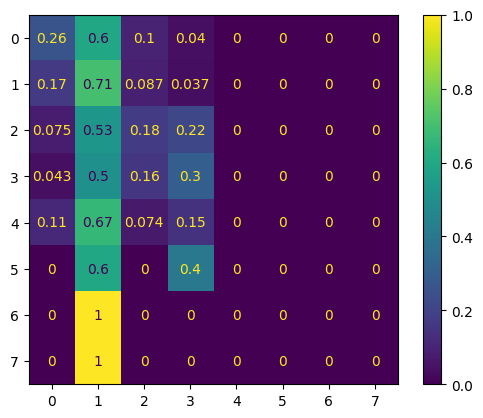

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

ConfusionMatrixDisplay(
    confusion_matrix(y_test, rfc.predict(X_test), normalize="true"),
    display_labels=sorted(y.unique())               
).plot()

In [92]:
rfc.feature_names_in_, rfc.feature_importances_

(array(['region', 'living_start_year', 'flat_total_area', 'flat_rooms',
        'flat_price', 'rel_price'], dtype=object),
 array([0.13963623, 0.23016526, 0.21088188, 0.05725433, 0.15437222,
        0.20769008]))

In [15]:
kouz_base = pd.read_csv("КОУЖ_2022_Датасет_по_домохозяйствам_основной.csv", sep=";")
kouz_add = pd.read_csv("КОУЖ_2022_Датасет_по_домохозяйствам_дополнительный.csv", sep=";")
kouz = pd.concat([kouz_base, kouz_add])
kouz.head(2)

,H00_02,H00_04,H00_06,H00_07,H00_08,H00_09,H00_10,H00_11,H00_12,H00_13,H00_14,H01_15,H02_01,H02_02,H02_03,H02_04,H02_05_01,H02_05_02,H02_05_03,H02_05_04,H02_05_05,H02_06_01,H02_06_02,H02_06_03,H02_06_04,H02_07,H02_08_01,H02_08_02,H02_08_03,H02_08_04,H02_09_01,H02_09_02,H02_09_03,H02_09_04,H02_09_05,H02_09_06,H02_09_07,H02_09_08,H02_09_09,H02_10,H02_11,H02_111,H02_12_01,H02_12_02,H02_12_03,H02_12_04,H02_13_01_01,H02_13_01_02,H02_13_02_01,H02_13_02_02,H02_13_03_01,H02_13_03_02,H02_13_04_02,H02_14,H02_141,H02_15_01,H02_15_02,H02_15_03,H02_15_04,H02_15_05,H02_15_06,H02_16_01_01,H02_16_01_02,H02_16_02_01,H02_16_02_02,H02_16_03_01,H02_16_03_02,H02_16_04_01,H02_16_04_02,H02_16_05_01,H02_16_05_02,H02_17_01,H02_17_02,H02_18,H02_19_01,H02_19_02,H02_19_03,H02_191_01,H02_191_02,H02_20,H02_21,H02_22,H02_22a_01,H02_22a_02,H02_22a_03,H02_221_01,H02_221_02,H02_221_03,H02_23,H02_24_01,H02_24_02,H02_24_03,H02_24_04,H02_25,H02_26,H02_27,H02_28_01,H02_28_02,H02_28_03,H02_281,H02_29,H02_30,H02_301,H02_31_01,H02_31_02,H02_31_03,H02_31_04,H02_31_05,H02_31_06,H02_31_07,H02_311,H02_32_01,H02_32_02,H02_32_03,H02_32_04,H02_32_05,H02_32_06,H02_33,H02_34_01,H02_34_02,H02_34_03,H02_34_04,H02_35,H02_350,H02_351,H02_352,H02_353,H02_354_01,H02_354_02,H02_354_03,H02_354_04,H02_354_05,H02_354_06,H02_354_07,H02_355_01_01,H02_355_02_01,H02_355_03_01,H02_355_04_01,H02_355_05_01,H02_355_01_02,H02_355_02_02,H02_355_03_02,H02_355_04_02,H02_355_05_02,H02_356_01,H02_356_02,H02_356_03,H02_356_04,H02_356_05,H02_356_06,H02_356_07,H02_36_01_01,H02_36_01_02,H02_36_02_01,H02_36_02_02,H02_36_04_01,H02_36_04_02,H02_36_05_01,H02_36_05_02,H02_36_06_01,H02_36_06_02,H02_36_07_01,H02_36_07_02,H02_36_08_01,H02_36_08_02,H02_40_01,H02_40_02,H02_41_01,H02_41_02,H02_41_03,H02_41_04,H02_41_05,H02_41_06,H02_41_07,H02_41_08,H02_41_09,H02_42_01_01,H02_42_02_01,H02_42_03_01,H02_42_04_01,H02_42_01_02,H02_42_02_02,H02_42_03_02,H02_42_04_02,H02_42_01_03,H02_42_02_03,H02_42_03_03,H02_42_04_03,H02_43_01,H02_43_02,H02_43_03,H02_43_04,H02_43_05,H02_431,H02_44_01_01,H02_44_02_01,H02_44_03_01,H02_44_04_01,H02_44_05_01,H02_44_01_02,H02_44_02_02,H02_44_03_02,H02_44_04_02,H02_44_05_02,H02_44_01_03,H02_44_02_03,H02_44_03_03,H02_44_04_03,H02_44_05_03,H02_441_01_01,H02_441_02_01,H02_441_03_01,H02_441_04_01,H02_441_01_02,H02_441_02_02,H02_441_03_02,H02_441_04_02,H02_45,H02_46,H02_47,H02_48,H02_49,H02_501_01,H02_501_02,H02_501_03,H02_501_04,H02_501_05,H02_501_06,H02_501_07,H02_502_01,H02_502_02,H02_502_03,H02_502_04,H02_502_05,H02_502_06,H02_502_07,H02_503_01,H02_503_02,H02_503_03,H02_503_04,H02_503_05,H02_503_06,H02_503_07,H03_01,H03_02,H03_03_01,H03_03_02,H03_04,H03_05,H03_06_01,H03_06_02,H03_06_03,H03_06_04,H03_06_05,H03_06_06,H04_01_01,H04_01_02,H04_01_03,H04_01_04,H04_01_05,H04_01_06,H04_01_07,H04_01_08,H04_01_09,H04_01_10,H04_01_11,H04_01_12,H04_01_13,H04_01_14,H04_01_15,H04_01_16,H04_01_17,H04_02_01_01,H04_02_01_02,H04_02_02,H04_021,H04_03,H04_04_01,H04_04_02,H04_04_03,H04_04_04,H04_04_05,H04_04_06,H04_04_07,H04_04_08,H04_04_09,H04_05,H04_051,H04_06_01,H04_06_02,H04_07_01,H04_07_02,H04_07_03,H04_07_04,H04_07_05,H04_07_06,H04_07_07,H04_07_08,H04_07_09,H04_08,H05_01,H05_02_01_01,H05_02_02_01,H05_02_03_01,H05_02_04_01,H05_02_05_01,H05_02_06_01,H05_02_07_01,H05_02_08_01,H05_02_09_01,H05_02_10_01,H05_02_11_01,H05_02_12_01,H05_02_13_01,H05_02_14_01,H05_02_15_01,H05_02_16_01,H05_02_17_01,H05_02_18_01,H05_02_01_02,H05_02_02_02,H05_02_03_02,H05_02_04_02,H05_02_05_02,H05_02_06_02,H05_02_07_02,H05_02_08_02,H05_02_09_02,H05_02_10_02,H05_02_11_02,H05_02_12_02,H05_02_13_02,H05_02_14_02,H05_02_15_02,H05_02_16_02,H05_02_17_02,H05_02_18_02,H05_02_01_03,H05_02_02_03,H05_02_03_03,H05_02_04_03,H05_02_05_03,H05_02_06_03,H05_02_07_03,H05_02_08_03,H05_02_09_03,H05_02_10_03,H05_02_11_03,H05_02_12_03,H05_02_13_03,H05_02_14_03,H05_02_15_03,H05_02_16_03,H05_02_17_03,H05_02_18_03,H05_02_01_04,H05_02_02_04,H05_02_03_04,H05_02_04_04,H05_02_05_04,H05_02_06_04,H05_02_07_04,H05_02_08_04,H05_02_09_04,H05_02_10_04,H05_02_11_04,H05_02_1

In [16]:
reg_codes = pd.read_excel("Коды_регионов.xlsx")
reg_codes.columns = ["region_code", "region"]

In [58]:
features = {
    "H00_02": "region_code",
    "H02_06_01": "flat_area_total",
    #"H02_06_03": "flat_n_rooms",
    "H02_11": "house_construction_year",
    "H02_111": "house_wall_material",
    "H02_13_01_01": "house_has_elevator",
    "H02_13_02_01": "house_has_chute",
    "H02_14": "house_quality",
    "H02_141": "flat_floor",
    "H02_16_01_01": "house_has_playground",
    "H02_16_02_01": "house_has_sportsground",
    "H02_16_03_01": "house_has_parking",
    #"H02_16_05_01": "house_has_containers",
    "H02_18": "house_cold_water_type",
    "H02_22": "house_serwage_type",
    "H02_27": "house_hot_water_type",
    "H02_29": "house_heating_type",
    "H02_32_01": "house_gas_counter_presence",
}
target = {"CHLIC": "flat_inhabitants_count"}

data_kouz = kouz.loc[
    (kouz["H02_01"] == 1) # whole flat households
][list(features) + list(target)]
data_kouz.columns = list(features.values()) + list(target.values())
data_kouz.replace(-7.0, np.nan, inplace=True)
data_kouz.dropna(inplace=True)

data_kouz["flat_area_total"] = data_kouz["flat_area_total"].round()
data_kouz["house_has_elevator"] = (data_kouz["house_has_elevator"] - 2.0).astype(bool) # 2.0 is False
data_kouz["house_has_chute"] = (data_kouz["house_has_chute"] - 2.0).astype(bool) # 2.0 is False
data_kouz["house_has_playground"] = (data_kouz["house_has_playground"] - 2.0).astype(bool) # 2.0 is False
data_kouz["house_has_sportsground"] = (data_kouz["house_has_sportsground"] - 2.0).astype(bool) # 2.0 is False
data_kouz["house_has_parking"] = (data_kouz["house_has_parking"] - 2.0).astype(bool) # 2.0 is False
#data_kouz["house_has_containers"] = (data_kouz["house_has_containers"] - 2.0).astype(bool) # 2.0 is False

data_kouz["house_quality"] = data_kouz["house_quality"] == 1.0 # only 1.0 is official alarm status
data_kouz["house_gas_counter_presence"] = (data_kouz["house_gas_counter_presence"] - 3.0).astype(bool) # 3.0 is not applicable = no gas
data_kouz.rename(
    columns={
        "house_quality": "house_is_alarm",
        "house_gas_counter_presence": "house_has_gas"
    }, 
    inplace=True
)
data_kouz = data_kouz.merge(reg_codes, how="left")
data_kouz.drop(columns=["region_code"], inplace=True)

data_kouz[data_kouz.select_dtypes(float).columns] = data_kouz.select_dtypes(float).astype(int)
data_kouz.head(2)

,flat_area_total,house_construction_year,house_wall_material,house_has_elevator,house_has_chute,house_is_alarm,flat_floor,house_has_playground,house_has_sportsground,house_has_parking,house_cold_water_type,house_serwage_type,house_hot_water_type,house_heating_type,house_has_gas,flat_inhabitants_count,region
0,52,5,1,False,False,False,1,True,True,True,1,1,2,1,True,4,Самарская область
1,65,5,2,False,True,False,2,True,False,False,1,1,1,1,True,4,Самарская область


In [53]:
data_kouz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54127 entries, 0 to 54126
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   flat_area_total          54127 non-null  int64 
 1   house_construction_year  54127 non-null  int64 
 2   house_wall_material      54127 non-null  int64 
 3   house_has_elevator       54127 non-null  bool  
 4   house_has_chute          54127 non-null  bool  
 5   house_is_alarm           54127 non-null  bool  
 6   flat_floor               54127 non-null  int64 
 7   house_has_playground     54127 non-null  bool  
 8   house_has_sportsground   54127 non-null  bool  
 9   house_has_parking        54127 non-null  bool  
 10  house_has_containers     54127 non-null  bool  
 11  house_cold_water_type    54127 non-null  int64 
 12  house_serwage_type       54127 non-null  int64 
 13  house_hot_water_type     54127 non-null  int64 
 14  house_heating_type       54127 non-nul

In [2]:
hse = pd.read_spss("r32h_os_71.sav")

In [3]:
features = {
    "region": "region",
    "bbc6": "flat_area_total",
    "bbc5.1": "flat_rooms",
    "bbc1.1": "flat_price",
    "bbc7.1": "has_central_heating",
    "bbc7.2": "has_central_water",
    "bbc13": "has_individual_water",
    "bbc7.3": "has_hot_water",
    "bbc7.5": "has_central_serwage",
    "bbc15": "has_autonomous_serwage",
    "bbc7.7": "has_gas",
}
target = {"bb_nfm": "flat_inhabitants_count"}
data_hse = hse.loc[hse["bbc3"] == "Отдельную квартиру"][list(features) + list(target)]
data_hse.rename(columns=(features | target), inplace=True)
data_hse.replace(["ЗАТРУДНЯЮСЬ ОТВЕТИТЬ", "ОТКАЗ ОТ ОТВЕТА", "НЕТ ОТВЕТА", "ЖИЛЬЕ НЕ ПОДЛЕЖИТ ПРОДАЖЕ", "ЖИЛЬЕ ПРОДАТЬ НЕВОЗМОЖНО"], np.nan, inplace=True)
data_hse = data_hse.loc[data_hse["region"] == "Москва"]
data_hse["region"] = pd.Categorical(data_hse["region"]).codes
data_hse[["flat_area_total", "flat_rooms", "flat_price"]] = data_hse[["flat_area_total", "flat_rooms", "flat_price"]].astype(float)
data_hse["rel_price"] = data_hse["flat_price"] / data_hse["flat_area_total"]

data_hse["house_cold_water_type"] = data_hse["has_central_water"].map({"Да": 1.0})
data_hse["house_cold_water_type"] = data_hse["house_cold_water_type"].combine_first(
    data_hse["has_individual_water"].map({"Да": 2.0, "Нет": 4.0})
)
data_hse.drop(columns=["has_central_water", "has_individual_water"], inplace=True)

data_hse["house_serwage_type"] = data_hse["has_central_serwage"].map({"Да": 1.0})
data_hse["house_serwage_type"] = data_hse["house_cold_water_type"].combine_first(
    data_hse["has_autonomous_serwage"].map({"Да": 2.0, "Нет": 4.0})
)
data_hse.drop(columns=["has_central_serwage", "has_autonomous_serwage"], inplace=True)

data_hse["house_hot_water_type"] = data_hse["has_hot_water"].map({"Да": 1.0, "Нет": 3.0})
data_hse["house_heating_type"] = data_hse["has_central_heating"].map({"Да": 1.0, "Нет": 4.0})
data_hse["house_has_gas"] = data_hse["has_gas"].map({"Да": True, "Нет": False})
data_hse.drop(columns=["has_central_heating", "has_hot_water", "has_gas"], inplace=True)

#data_hse.dropna(inplace=True)
data_hse.head()

/tmp/ipykernel_26647/3692857385.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_hse.replace(["ЗАТРУДНЯЮСЬ ОТВЕТИТЬ", "ОТКАЗ ОТ ОТВЕТА", "НЕТ ОТВЕТА", "ЖИЛЬЕ НЕ ПОДЛЕЖИТ ПРОДАЖЕ", "ЖИЛЬЕ ПРОДАТЬ НЕВОЗМОЖНО"], np.nan, inplace=True)
/tmp/ipykernel_26647/3692857385.py:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data_hse.replace(["ЗАТРУДНЯЮСЬ ОТВЕТИТЬ", "ОТКАЗ ОТ ОТВЕТА", "НЕТ ОТВЕТА", "ЖИЛЬЕ НЕ ПОДЛЕЖИТ ПРОДАЖЕ", "ЖИЛЬЕ ПРОДАТЬ НЕВОЗМОЖНО"], np.nan, inplace=True)
/tmp/ipykernel_26647/3692857385.py:17: FutureWarning: Downcasting behavio

,region,flat_area_total,flat_rooms,flat_price,flat_inhabitants_count,rel_price,house_cold_water_type,house_serwage_type,house_hot_water_type,house_heating_type,house_has_gas
3672,16,58.0,2.0,14000000.0,5.0,241379.310345,1.0,1.0,1.0,1.0,True
3673,16,38.0,2.0,8000000.0,1.0,210526.315789,1.0,1.0,1.0,1.0,True
3674,16,48.3,2.0,NaN,2.0,NaN,1.0,1.0,1.0,1.0,True
3675,16,44.3,2.0,9000000.0,5.0,203160.270880,1.0,1.0,1.0,1.0,True
3676,16,38.6,2.0,6000000.0,1.0,155440.414508,1.0,1.0,1.0,1.0,True


In [4]:
data_hse.info()

<class 'pandas.core.frame.DataFrame'>
Index: 366 entries, 3672 to 4741
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   region                  366 non-null    int8    
 1   flat_area_total         366 non-null    float64 
 2   flat_rooms              366 non-null    float64 
 3   flat_price              202 non-null    float64 
 4   flat_inhabitants_count  366 non-null    float64 
 5   rel_price               202 non-null    float64 
 6   house_cold_water_type   366 non-null    float64 
 7   house_serwage_type      366 non-null    float64 
 8   house_hot_water_type    366 non-null    category
 9   house_heating_type      366 non-null    category
 10  house_has_gas           366 non-null    category
dtypes: category(3), float64(7), int8(1)
memory usage: 32.7 KB


In [5]:
X = data_hse.drop(columns="flat_inhabitants_count")
y = data_hse["flat_inhabitants_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)
X_train.shape, y_test.shape

((292, 10), (74,))

In [6]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
balanced_accuracy_score(y_test, rfc.predict(X_test), adjusted=True)

/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


np.float64(0.03391608391608394)

In [80]:
rfc.feature_names_in_, rfc.feature_importances_

(array(['region', 'flat_total_area', 'flat_rooms', 'flat_price',
        'rel_price', 'has_central_heating_Да', 'has_central_heating_Нет',
        'has_water_Да', 'has_water_Нет', 'has_hot_water_Да',
        'has_hot_water_Нет', 'has_serwage_Да', 'has_serwage_Нет',
        'has_gas_Да', 'has_gas_Нет'], dtype=object),
 array([0.15362847, 0.25144431, 0.06915384, 0.18376844, 0.23713546,
        0.00854652, 0.00835285, 0.00269143, 0.00266228, 0.01543125,
        0.01510629, 0.00531112, 0.00541954, 0.02070023, 0.02064797]))

In [59]:
data = pd.concat([data_kouz])
data["region"] = data["region"].str.split(",", expand=True)[0]
data.replace(["ЗАТРУДНЯЮСЬ ОТВЕТИТЬ", "ОТКАЗ ОТ ОТВЕТА", "НЕТ ОТВЕТА", "ЖИЛЬЕ НЕ ПОДЛЕЖИТ ПРОДАЖЕ", "ЖИЛЬЕ ПРОДАТЬ НЕВОЗМОЖНО"], np.nan, inplace=True)
#data[["flat_area_total", "flat_rooms", "flat_price", "flat_inhabitants_count", "living_start_year"]] = data[["flat_area_total", "flat_rooms", "flat_price", "flat_inhabitants_count", "living_start_year"]].astype(float)
#data["flat_rel_price"] = data["flat_price"] / data["flat_area_total"]
data[["house_has_gas", "house_has_elevator", "house_has_chute", "house_has_parking", "house_is_alarm"]] = (
    data[["house_has_gas", "house_has_elevator", "house_has_chute", "house_has_parking", "house_is_alarm"]].astype(bool)
)
data["region"] = data["region"].replace({
    "Казань": "Республика Татарстан",
    "Владивосток": "Приморский край",
    "Краснодар": "Краснодарский край",
    "Красноярск": "Красноярский край",
    "Курган": "Курганская область",
    "Липецк": "Липецкая область",
    "Нижний Новгород": "Нижегородская область",
    "Саратов": "Саратовская область",
    "Смоленск": "Смоленская область",
    "Томск": "Томская область",
    "Тула": "Тульская область",
    "Челябинск": "Челябинская область",
    "г. Москва": "Москва",
    "г. Санкт-Петербург": "Санкт-Петербург",
    "г. Севастополь": "Севастополь",
})
data = data.loc[data["region"].isin(["Москва"])]
data["region"] = pd.Categorical(data["region"]).codes

#data[["flat_area_total", "flat_rel_price"]] = data[["flat_area_total", "flat_rel_price"]].round()
#data[data.select_dtypes(float).columns] = data.select_dtypes(float).astype(int)

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5949 entries, 25526 to 54125
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   flat_area_total          5949 non-null   int64
 1   house_construction_year  5949 non-null   int64
 2   house_wall_material      5949 non-null   int64
 3   house_has_elevator       5949 non-null   bool 
 4   house_has_chute          5949 non-null   bool 
 5   house_is_alarm           5949 non-null   bool 
 6   flat_floor               5949 non-null   int64
 7   house_has_playground     5949 non-null   bool 
 8   house_has_sportsground   5949 non-null   bool 
 9   house_has_parking        5949 non-null   bool 
 10  house_cold_water_type    5949 non-null   int64
 11  house_serwage_type       5949 non-null   int64
 12  house_hot_water_type     5949 non-null   int64
 13  house_heating_type       5949 non-null   int64
 14  house_has_gas            5949 non-null   bool 
 15  flat

In [60]:
X = data.drop(columns="flat_inhabitants_count")
y = data["flat_inhabitants_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)
X_train.shape, y_test.shape

((4461, 16), (1488,))

In [68]:
pd.Series(y_train).value_counts()

flat_inhabitants_count
2    1587
1    1386
3     962
4     366
5     127
6      28
7       5
Name: count, dtype: int64

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder

In [56]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)

RandomForestClassifier()

In [57]:
balanced_accuracy_score(y_test, rfc.predict(X_test))

np.float64(0.6076771240433961)

In [48]:
p = Pipeline([
    (
        "preprocess", 
        ColumnTransformer(
            [
                (
                    "categorical", 
                    OneHotEncoder(), 
                    [
                        "house_wall_material",
                        "house_has_elevator",
                        "house_has_chute",
                        "house_is_alarm",
                        "house_has_playground",
                        "house_has_sportsground",
                        "house_has_parking",
                        "house_cold_water_type",
                        "house_serwage_type",
                        "house_hot_water_type",
                        "house_heating_type",
                        "house_has_gas",                        
                    ]
                ),
                (
                    "numeric",
                    "passthrough",
                    [
                        "flat_area_total",
                        "house_construction_year",
                        "flat_floor",
                        #"flat_n_rooms",
                    ]
                )
            ],
            remainder="drop"
        ),
    ),
    (
        "estimate",
        RandomForestClassifier()
    )
])

In [49]:
p.fit(X_train, y_train)
balanced_accuracy_score(y_test, p.predict(X_test))

np.float64(0.5966186869308557)

In [70]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

gs = GridSearchCV(
    estimator=CatBoostClassifier(iterations=50, verbose=50),
    param_grid={
        "learning_rate": [0.001, 0.01, 0.1, 1],
        "depth": range(2, 13, 3),
    },
    scoring="balanced_accuracy",
    cv=5, 
    verbose=2
)
gs.fit(X, y)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
0:	learn: 1.9449731	total: 3.62ms	remaining: 178ms
49:	learn: 1.8962078	total: 245ms	remaining: 0us
[CV] END .......................depth=2, learning_rate=0.001; total time=   0.5s
0:	learn: 1.9449740	total: 3.47ms	remaining: 170ms
49:	learn: 1.8973079	total: 201ms	remaining: 0us
[CV] END .......................depth=2, learning_rate=0.001; total time=   0.4s
0:	learn: 1.9449697	total: 6.08ms	remaining: 298ms
49:	learn: 1.8964067	total: 223ms	remaining: 0us
[CV] END .......................depth=2, learning_rate=0.001; total time=   0.4s
0:	learn: 1.9449736	total: 3.87ms	remaining: 190ms
49:	learn: 1.8965499	total: 217ms	remaining: 0us
[CV] END .......................depth=2, learning_rate=0.001; total time=   0.4s
0:	learn: 1.9449742	total: 4.26ms	remaining: 209ms
49:	learn: 1.8974457	total: 226ms	remaining: 0us
[CV] END .......................depth=2, learning_rate=0.001; total time=   0.4s
0:	learn: 1.9365813	total: 4.76ms	

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostClassifier object at 0x72f9393a5480>,
             param_grid={'depth': range(2, 13, 3),
                         'learning_rate': [0.001, 0.01, 0.1, 1]},
             scoring='balanced_accuracy', verbose=2)

In [71]:
gs.best_score_, gs.best_estimator_

(np.float64(0.48787156936485676),
 <catboost.core.CatBoostClassifier at 0x72f93932d060>)

In [72]:
from sklearn.feature_selection import RFECV

r = RFECV(
    RandomForestClassifier(n_jobs=-1),
    cv=5,
    scoring="balanced_accuracy",
    verbose=2,
)
r.fit(X, y)

Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fittin

RFECV(cv=5, estimator=RandomForestClassifier(n_jobs=-1),
      scoring='balanced_accuracy', verbose=2)

In [78]:
r.support_, r.feature_names_in_

(array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False,  True,  True,  True,  True, False]),
 array(['flat_area_total', 'house_construction_year',
        'house_wall_material', 'house_has_elevator', 'house_has_chute',
        'house_is_alarm', 'flat_floor', 'house_has_playground',
        'house_has_sportsground', 'house_has_parking',
        'house_cold_water_type', 'house_serwage_type',
        'house_hot_water_type', 'house_heating_type', 'house_has_gas',
        'region'], dtype=object))

In [79]:
r.cv_results_

{'mean_test_score': array([0.1903897 , 0.25361408, 0.33494731, 0.4086318 , 0.45280297,
        0.49394835, 0.55713304, 0.58328424, 0.58384596, 0.56379538,
        0.55542481, 0.56321955, 0.58697916, 0.5909974 , 0.56359706,
        0.56033449]),
 'std_test_score': array([0.01461546, 0.04550087, 0.06026755, 0.12109484, 0.13004263,
        0.15014857, 0.12124099, 0.12685757, 0.12004171, 0.14263815,
        0.14463967, 0.13788584, 0.12077001, 0.11253351, 0.14118395,
        0.13876749]),
 'split0_test_score': array([0.17452702, 0.2002394 , 0.28202483, 0.29085497, 0.33651352,
        0.31549359, 0.48151406, 0.51952756, 0.53178141, 0.39650598,
        0.40497522, 0.40126675, 0.54833292, 0.55174858, 0.39849255,
        0.40597584]),
 'split1_test_score': array([0.18339247, 0.22272407, 0.28652788, 0.29516897, 0.31900674,
        0.35262063, 0.40993912, 0.4021984 , 0.41491416, 0.42692696,
        0.40342658, 0.43894689, 0.41408187, 0.43723081, 0.43188258,
        0.43018027]),
 'split2_test_sco

In [66]:
gs.cv_results_

{'mean_fit_time': array([0.51449862, 1.48980546, 2.54286938, 4.34151354, 4.13930116,
        0.62388215, 1.64291115, 3.04349794, 4.26601663, 4.60813241,
        0.46833649, 1.21901999, 2.22021146, 3.00346513, 4.15923128,
        0.56977153, 1.96646295, 3.00391083, 3.85831771, 4.57049651,
        0.48335471, 2.00496798, 2.8031044 , 3.78452964, 6.44889674,
        0.94211683, 2.96279168, 3.76939368, 4.07169251, 6.48827443,
        0.6692008 , 2.22806096, 3.31588631, 4.1806694 , 4.79645305,
        0.5780015 , 1.66398449, 2.93032432, 3.89650693, 7.26818824,
        1.19995351, 2.92361336, 4.42181931, 4.96384168, 4.89282031,
        0.55535431, 1.73828855, 3.2729353 , 4.40362735, 5.58482761]),
 'std_fit_time': array([0.03471997, 0.066756  , 0.17505837, 0.38559738, 0.07763225,
        0.0912872 , 0.26850339, 0.66483787, 0.43700323, 0.35659984,
        0.04677659, 0.07987361, 0.08659659, 0.22055507, 0.36743928,
        0.07721027, 0.27878735, 0.25905105, 0.22441104, 0.46254398,
        0.026

In [191]:
from sklearn.model_selection import GridSearchCV

gs = GridSearchCV(
    estimator=vc,
    param_grid={
        "e1__estimate__max_depth": range(2, 12, 3),
        "e2__estimate__max_depth": range(2, 12, 3),
        "voting": ["hard", "soft"]
    },
    scoring="balanced_accuracy",
    cv=3, 
    verbose=2
)
gs.fit(X, y)

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/home/pavel/.cache/pypoetry/virtualenvs/moscow-housing-vacancy-rate-TDZpt-C6-py3.10/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=2, voting=hard; total time=   4.2s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=2, voting=hard; total time=   3.9s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=2, voting=hard; total time=   4.2s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=2, voting=soft; total time=   4.0s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=2, voting=soft; total time=   4.3s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=2, voting=soft; total time=   4.2s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=5, voting=hard; total time=   5.4s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=5, voting=hard; total time=   4.8s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=5, voting=hard; total time=   4.4s
[CV] END e1__estimate__max_depth=2, e2__estimate__max_depth=5, voting=soft; total time=   4.6s
[CV] END e1__estimate__max_depth=2, e2__estimate__

GridSearchCV(cv=3,
             estimator=VotingClassifier(estimators=[('e1',
                                                     Pipeline(steps=[('preprocess',
                                                                      ColumnTransformer(transformers=[('cbr_features',
                                                                                                       StandardScaler(),
                                                                                                       ['flat_total_area',
                                                                                                        'flat_rooms',
                                                                                                        'flat_price',
                                                                                                        'living_start_year',
                                                                                                        'rel_price'])])),
                                                                     ('estimate',
                                                                      RandomForestClassifier(max_depth=5,
                                                                                             n_estimators=500))])),
                                                    ('e2',
                                                     Pipeline(steps=[('preprocess',
                                                                      Colum...
                                                                                                        'has_gas']),
                                                                                                      ('numeric_features',
                                                                                                       StandardScaler(),
                                                                                                       ['flat_total_area',
                                                                                                        'flat_rooms',
                                                                                                        'flat_price',
                                                                                                        'rel_price'])])),
                                                                     ('estimate',
                                                                      RandomForestClassifier(max_depth=5,
                                                                                             n_estimators=500))]))],
                                        voting='soft'),
             param_grid={'e1__estimate__max_depth': range(2, 12, 3),
                         'e2__estimate__max_depth': range(2, 12, 3),
                         'voting': ['hard', 'soft']},
             scoring='balanced_accuracy', verbose=2)

In [192]:
gs.best_score_, gs.best_estimator_

(np.float64(0.1270433147514399),
 VotingClassifier(estimators=[('e1',
                               Pipeline(steps=[('preprocess',
                                                ColumnTransformer(transformers=[('cbr_features',
                                                                                 StandardScaler(),
                                                                                 ['flat_total_area',
                                                                                  'flat_rooms',
                                                                                  'flat_price',
                                                                                  'living_start_year',
                                                                                  'rel_price'])])),
                                               ('estimate',
                                                RandomForestClassifier(max_depth=11,
                               

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

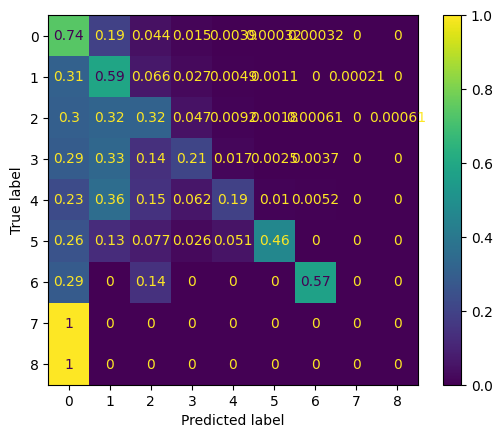

In [36]:
ConfusionMatrixDisplay(confusion_matrix(y_test, rfc.predict(X_test), normalize="true")).plot()

In [188]:
data.groupby("flat_rooms")["flat_inhabitants_count"].describe()

,count,mean,std,min,25%,50%,75%,max
flat_rooms,,,,,,,,
1.0,821.0,1.831912,0.986991,1.0,1.0,2.0,2.0,8.0
2.0,2627.0,2.334602,1.278578,1.0,1.0,2.0,3.0,10.0
3.0,1765.0,2.866856,1.456806,1.0,2.0,3.0,4.0,9.0
4.0,228.0,3.083333,1.524277,1.0,2.0,3.0,4.0,8.0
5.0,9.0,3.777778,2.386304,1.0,2.0,3.0,5.0,9.0
6.0,1.0,4.000000,NaN,4.0,4.0,4.0,4.0,4.0
